In [1]:
%load_ext rpy2.ipython

ModuleNotFoundError: No module named 'rpy2'

In [1]:
f1_data <- read.csv("f1-scores.csv")
f1_data

NameError: name 'f1_data' is not defined

In [ ]:
combos <- expand.grid(list(prompt=c("zero-shot","one-shot"),input=c("text","image")), stringsAsFactors=FALSE) 
combos$label <- apply(combos,1,paste,collapse=";")
combos

prompt,input,label
<chr>,<chr>,<chr>
zero-shot,text,zero-shot;text
one-shot,text,one-shot;text
zero-shot,image,zero-shot;image
one-shot,image,one-shot;image


In [ ]:
mnames <- unique(f1_data$model)
f1_mat <- do.call(rbind,lapply(mnames, \(m) {
    vals <- do.call(cbind,lapply(seq_len(nrow(combos)), \(i) {
        combo <- combos[i,]
        with(f1_data,f1[which(model == m & prompt == combo$prompt & input == combo$input)])
    }))
}))
rownames(f1_mat) <- mnames
colnames(f1_mat) <- combos$label
f1_mat

,zero-shot;text,one-shot;text,zero-shot;image,one-shot;image
GPT4.1-mini,63.0,66.6,20.1,21.1
Gemma3-27B,17.2,17.2,51.5,27.5
Llama3-170B,39.9,40.6,NA,NA
Mistral-24B,31.4,30.2,23.4,16.6
NuExtract-4B,27.9,NA,NA,NA
GliNER,6.2,NA,6.2,NA


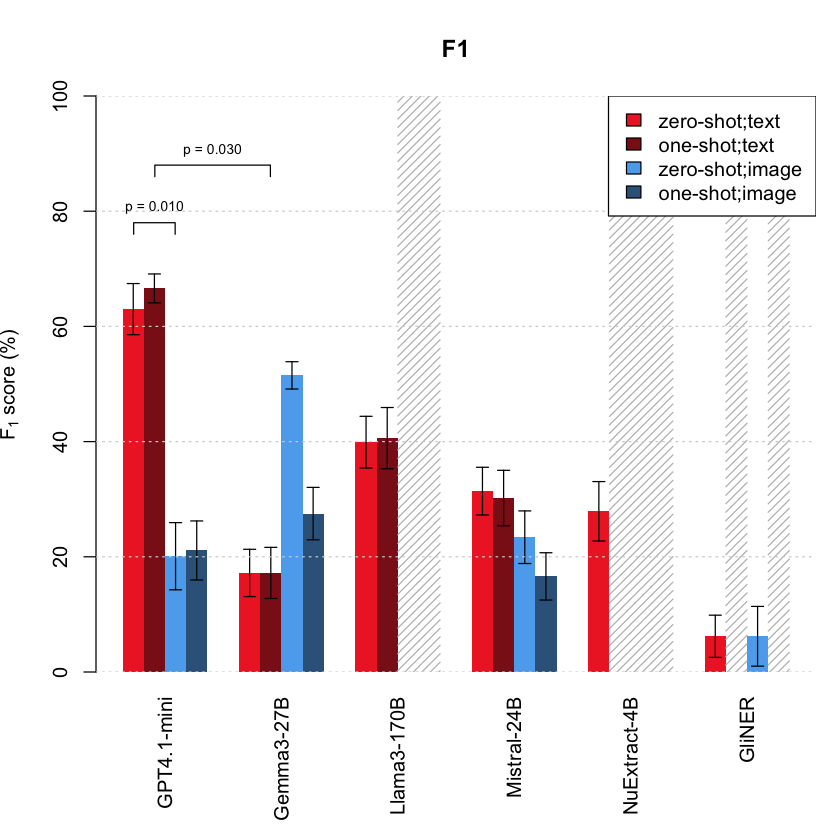

In [ ]:

#make up MOCK error values for now!!! TODO: Replace this with real data
stderr <- matrix(rnorm(6*4,10,2),nrow=4)
pvals <- c(0.03,0.01)

# mycolors <- expand.grid(list(c("firebrick", "darkolivegreen"), c(2,4)))|> apply(1,paste,collapse="")
mycolors <- c("firebrick2", "firebrick4", "steelblue2", "steelblue4")

# options(repr.plot.width = 2, repr.plot.height = 1)

#set margins and axis label orientations
op <- par(las=3, mar=c(7,4,4,1))
#draw plot
xs <- barplot(
    t(f1_mat), beside=TRUE, space=c(0,1.5),
    ylim=c(0,100),
    col=mycolors, border=NA, 
    ylab=expression(F[1]~"score (%)"), main="F1"
)
#draw the error bars
yogitools::errorBars(xs, t(f1_mat), stderr, l=.05)
#determine x-coordinates of missing values
xna <- xs[apply(t(f1_mat),1:2,is.na)]
#add hatching at missing value positions
rect(xna-0.5, 0, xna+0.5, 100, col="gray", density=20,border=NA)
drawPvalBracket(pvals[[1]], xs[2,1], xs[2,2], h = 88, th = 2)
drawPvalBracket(pvals[[2]], xs[1,1], xs[3,1], h = 78, th = 2)
#add grid lines
grid(NA,NULL)
#add legend
legend("topright", colnames(f1_mat), fill=mycolors, bg="white")

par(op)

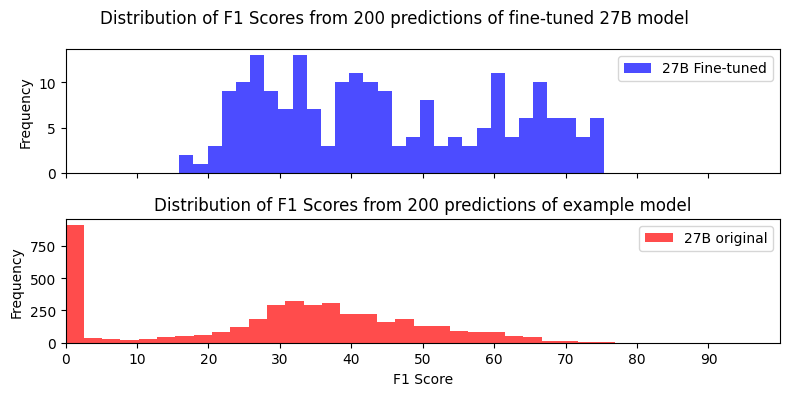

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import csv

f1score_lst_27b = []
with open("/u/lsong/labspace/lei_notebook/data/output_gemma-3-27b-it_1000ct.pkl_Hospitalfinal.csv","r") as file:
    samples_10 = csv.reader(file, delimiter=',')
    next(samples_10)
    for rows in samples_10:
        float_n = float(rows[7])
        #if float_n>0:
        f1score_lst_27b.append(float_n)

f1score_lst_aaron = []
with open("/u/lsong/labspace/lei_notebook/data/output_gemma-3-27b-it_manuscript.pkl_Hospitalfinal.csv","r") as file:
    samples_10 = csv.reader(file, delimiter=',')
    next(samples_10)
    for rows in samples_10:
        float_n = float(rows[7])
        #if float_n>0:
        f1score_lst_aaron.append(float_n)       

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# Row 1: Text modality
axes[0].hist(f1score_lst_27b, bins=30, color="blue", alpha=0.7, label="27B Fine-tuned")
axes[1].hist(f1score_lst_aaron, bins=30, color="red", alpha=0.7, label="27B original")

axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[0].set_ylabel("Frequency")
axes[0].legend()
# Set x-axis ticks to bin boundaries
plt.xticks(list(range(0, 100, 10)))
plt.xlim(0, 100)

# Labels and title
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.suptitle("Distribution of F1 Scores from 200 predictions of fine-tuned 27B model")
plt.title("Distribution of F1 Scores from 200 predictions of example model")
plt.tight_layout()
plt.show()

In [16]:
len(f1score_lst_27b)

200

In [32]:
import statistics

# Calculate the standard deviation from a sample of data
print("F1 Mean: ", statistics.mean(f1score_lst_27b), " F1 STD: ",statistics.stdev(f1score_lst_27b))
print("F1 Mean delta: ", (statistics.mean(f1score_lst_27b) - statistics.mean(f1score_lst_aaron)), " F1 STD delta: ",(statistics.stdev(f1score_lst_27b) - statistics.stdev(f1score_lst_aaron)))

F1 Mean:  44.83888436051546  F1 STD:  16.25619570856062
F1 Mean delta:  15.283109094369344  F1 STD delta:  -3.107835170914708


In [12]:
import json
a = json.loads('{"date_collected": "2021-09-02 18:17:09", "date_received": "2021-09-03 17:25:57", "date_verified": "2021-09-05 23:00:58", "report_type": "Molecular Genetics", "testing_context": "Research", "ordering_clinic": "Hospital for Sick Children (Toronto)", "testing_laboratory": "London Health Sciences Centre (London)", "sequencing_scope": "Targeted variant testing", "tested_genes": {"RUNX1T1": {"gene_symbol": "RUNX1T1", "refseq_mrna": "NM_175634.3"}, "TNFAIP3": {"gene_symbol": "TNFAIP3", "refseq_mrna": "NM_006290.4"}, "HOXA11": {"gene_symbol": "HOXA11", "refseq_mrna": "NM_005523.6"}, "BCR": {"gene_symbol": "BCR", "refseq_mrna": "NM_004327.4"}, "ARID5B": {"gene_symbol": "ARID5B", "refseq_mrna": "NM_032199.3"}, "TRIM24": {"gene_symbol": "TRIM24", "refseq_mrna": "NM_015905.3"}, "HEY1": {"gene_symbol": "HEY1", "refseq_mrna": "NM_012258.4"}, "HIST1H4E": {"gene_symbol": "HIST1H4E", "refseq_mrna": "NM_003545.3"}, "HNRNPA2B1": {"gene_symbol": "HNRNPA2B1", "refseq_mrna": "NM_002137.4"}, "XPC": {"gene_symbol": "XPC", "refseq_mrna": "NM_004628.5"}, "FOXO1": {"gene_symbol": "FOXO1", "refseq_mrna": "NM_002015.4"}, "MAF": {"gene_symbol": "MAF", "refseq_mrna": "NM_005360.5"}, "PRDM9": {"gene_symbol": "PRDM9", "refseq_mrna": "NM_020227.4"}, "CDK8": {"gene_symbol": "CDK8", "refseq_mrna": "NM_013303.3"}, "CDKN1B": {"gene_symbol": "CDKN1B", "refseq_mrna": "NM_004064.5"}, "FOSL2": {"gene_symbol": "FOSL2", "refseq_mrna": "NM_005253.4"}}, "num_tested_genes": 16, "sample_type": "Total DNA", "analysis_type": "Methylation analysis", "variants": [{"gene_symbol": "MAF", "variant_id": "VCV007002694", "chromosome": "chr16", "hgvsg": "g.3674450G>A", "hgvsc": "c.472G>A", "hgvsp": "p.Gly158Ser", "type": "missense", "transcript_id": "NM_005360.5", "exon": "1", "zygosity": "heterozygous", "interpretation": "Likely pathogenic", "mafac": 193, "mafan": 488979, "mafaf": 0.0003946328, "mega_hgvs": "NM_005360.5(MAF):[c.472G>A(p.Gly158Ser)]:[=]"}, {"gene_symbol": "TNFAIP3", "variant_id": "VCV002106757", "chromosome": "chr5", "hgvsg": "g.117265656G>T", "hgvsc": "c.1027G>T", "hgvsp": "p."}]}')
print(a)

{'date_collected': '2021-09-02 18:17:09', 'date_received': '2021-09-03 17:25:57', 'date_verified': '2021-09-05 23:00:58', 'report_type': 'Molecular Genetics', 'testing_context': 'Research', 'ordering_clinic': 'Hospital for Sick Children (Toronto)', 'testing_laboratory': 'London Health Sciences Centre (London)', 'sequencing_scope': 'Targeted variant testing', 'tested_genes': {'RUNX1T1': {'gene_symbol': 'RUNX1T1', 'refseq_mrna': 'NM_175634.3'}, 'TNFAIP3': {'gene_symbol': 'TNFAIP3', 'refseq_mrna': 'NM_006290.4'}, 'HOXA11': {'gene_symbol': 'HOXA11', 'refseq_mrna': 'NM_005523.6'}, 'BCR': {'gene_symbol': 'BCR', 'refseq_mrna': 'NM_004327.4'}, 'ARID5B': {'gene_symbol': 'ARID5B', 'refseq_mrna': 'NM_032199.3'}, 'TRIM24': {'gene_symbol': 'TRIM24', 'refseq_mrna': 'NM_015905.3'}, 'HEY1': {'gene_symbol': 'HEY1', 'refseq_mrna': 'NM_012258.4'}, 'HIST1H4E': {'gene_symbol': 'HIST1H4E', 'refseq_mrna': 'NM_003545.3'}, 'HNRNPA2B1': {'gene_symbol': 'HNRNPA2B1', 'refseq_mrna': 'NM_002137.4'}, 'XPC': {'gene_s

In [23]:
a["date_collected"]

'2021-09-02 18:17:09'